# PIT Top-5 Holdings Rotation — Review

**Goal.** Audit the point-in-time (PIT) top-5 holdings rotation against the sector ETF rotation and SPY buy-and-hold, on both the in-sample history window and the untouched 2025+ holdout. Everything in this notebook reads from the most recent `outputs/sector_rotation_report/` exports — no model is retrained here.

**Headline (from the latest run):**
- History selection rule: rank candidate strategies by Sharpe → CAGR → max-drawdown on the history slice; evaluate the unchanged winner on holdout.
- History winner: **regime_change / Sector ETF ML Quality Rotation** (Sharpe 0.94, CAGR 16.9%).
- Held-out 2025+ result: +28.1% total return, +11.7 pts vs SPY, holdout Sharpe 1.36 — but ranked **4 of 4** vs the ex-post oracle (`ml_5bar / Sector ETF ML Quality Rotation`), so the selection rule produced a winner that *did* beat SPY but was not the best of the four candidates with hindsight.

**Forward-bias checks performed for this run (summary, details in §2):**
- Holdings consumed only when `known_from_date <= signal_date`.
- Validation-quality prior built per signal year from folds strictly before that year.
- Entry on the trading bar after `signal_date`, exit at fixed horizon or 10% stop on first breach bar.
- Macro feature pipeline patched to remove a full-sample VIX3M backfill (`patch_vix3m_history`) and a `bfill()` on spot VIX (`patch_spot_vix_history`) — see §2.

**Section map**
1. Setup & data loading
2. Forward-bias controls
3. Data overview (periods, modes, regimes)
4. Strategy summary table
5. Equity curves — history vs holdout
6. Drawdowns
7. Per-period return distribution
8. Returns by regime
9. Turnover and trading cost
10. Stop-loss activity
11. Leaderboard and best-strategy assessment
12. Sector exposure heatmap
13. Conclusions and known caveats

## 1. Setup & data loading

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'sector_rotation_report'
print('report dir:', REPORT_DIR)

report dir: /Users/timursabitov/Dev/price_action/outputs/sector_rotation_report


In [2]:
period_log = pd.read_csv(
    REPORT_DIR / 'sector_ml_pit_top5_holdings_period_log.csv',
    parse_dates=['signal_date', 'entry_date', 'exit_date'],
)
summary = pd.read_csv(REPORT_DIR / 'sector_ml_pit_top5_holdings_strategy_summary.csv')
leaderboard = pd.read_csv(REPORT_DIR / 'sector_ml_pit_top5_holdings_leaderboard.csv')
with open(REPORT_DIR / 'sector_ml_pit_top5_holdings_best_strategy_assessment.json') as f:
    assessment = json.load(f)

print('period_log:', period_log.shape)
print('summary   :', summary.shape)
print('leaderboard:', leaderboard.shape)
print('assessment keys:', list(assessment)[:8], '...')

period_log: (215, 26)
summary   : (12, 18)
leaderboard: (4, 44)
assessment keys: ['selection_rule', 'candidate_count', 'selected_mode', 'selected_strategy_label', 'selected_history_rank', 'selected_holdout_rank', 'history_total_return', 'history_cagr'] ...


## 2. Forward-bias controls

The PIT runner enforces three layered controls. None of these are derived from the report files — they are baked into `backtest_top_holdings_rotation.py` and the upstream `sector_ml` training:

1. **Point-in-time holdings.** `_latest_known_sector_holdings` filters `holdings.known_from_date <= signal_date` before picking the latest disclosure. The constructor `_load_point_in_time_holdings` raises if any row has `known_from_date < as_of_date`, preventing back-dated disclosures from being used.
2. **Point-in-time validation-quality prior.** `_build_point_in_time_quality` (in `sector_ml.py`) restricts the fold pool for signal year *Y* to folds with `fold_year < Y`, so the score that re-weights sectors at a given signal date is built strictly from historical validation folds.
3. **Holdout isolation.** The walk-forward trainer (`expanding_walk_forward_splits` and the calendar splitter in `train.py`) enforces `train_end < holdout_start - gap_delta`. The holdout signal frame is then re-loaded from `sector_ml_holdout_signal_frame.csv`; the validation prior used to score it is built only from pre-holdout folds.

**Macro feature fix applied in this revision.** An audit of `macro_features.py` flagged two leakage sources upstream of the model:

- `patch_vix3m_history` originally computed full-sample OLS slope/intercept on the spot-VIX vs VIX3M overlap and used those coefficients to backfill VIX3M before its 2007 launch. Full-sample means the training rows before 2007 saw a synthetic VIX3M that was tuned with post-2007 observations. **Fix:** replaced with an expanding regression that uses only overlap rows up to and including each date.
- `patch_spot_vix_history` previously ended with `bfill()`, which propagates later spot-VIX values backward in time. **Fix:** removed; the VXO fallback via `combine_first` is sufficient and is causal because it picks the first-valid-of-two real, observed series.

Below we sanity-check the new VIX3M backfill is genuinely causal by mutating a *future* overlap point and confirming the synthetic past does not move.

In [3]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from price_action.macro_features import patch_spot_vix_history, patch_vix3m_history

idx = pd.date_range('2000-01-01', periods=10, freq='D')
spot = pd.Series([20, 22, 25, 18, 17, 19, 21, 23, 24, 22], index=idx, dtype=float)
vix3m = pd.Series([np.nan]*6 + [21.5, 22.5, 23.5, 22.0], index=idx)
base = pd.DataFrame({'spot_vix': spot, 'vix3m_level': vix3m})
mutated = base.copy()
mutated.loc[idx[-1], 'vix3m_level'] = 100.0  # mutate a future value

out_base = patch_vix3m_history(patch_spot_vix_history(base.copy()))
out_mut = patch_vix3m_history(patch_spot_vix_history(mutated.copy()))

diff = (out_base['vix3m_level'].iloc[:-1] - out_mut['vix3m_level'].iloc[:-1]).abs().fillna(0)
print('max delta on earlier dates after mutating future:', float(diff.max()))
assert float(diff.max()) == 0.0, 'forward-bias regression: future change affected past'
print('OK — VIX3M synthetic backfill is causal.')

max delta on earlier dates after mutating future: 0.0
OK — VIX3M synthetic backfill is causal.


## 3. Data overview

In [4]:
scope_mode = (
    period_log.groupby(['scope', 'mode'])
    .agg(
        first_signal=('signal_date', 'min'),
        last_signal=('signal_date', 'max'),
        periods=('signal_date', 'count'),
        regimes=('regime_label', 'nunique'),
    )
    .reset_index()
)
scope_mode

,scope,mode,first_signal,last_signal,periods,regimes
0,history,ml_5bar,2020-04-02,2026-03-02,157,5
1,history,regime_change,2020-04-02,2025-05-05,37,5
2,holdout,ml_5bar,2025-01-02,2026-02-25,18,2
3,holdout,regime_change,2025-01-02,2025-05-07,3,2


In [5]:
regime_periods = (
    period_log.groupby(['scope', 'mode', 'regime_label'])['signal_date']
    .count()
    .unstack(fill_value=0)
)
regime_periods

regime_label           Cash  Fragile Late-Cycle Watch  Inflationary Boom  \
scope   mode                                                               
history ml_5bar          50                         9                 51   
        regime_change    17                         4                  8   
holdout ml_5bar           1                         0                  0   
        regime_change     1                         0                  0   

regime_label           Liquidity Bubble Or Valuation Stretch  \
scope   mode                                                   
history ml_5bar                                           31   
        regime_change                                      5   
holdout ml_5bar                                           17   
        regime_change                                      2   

regime_label           Rate-Shock Regime  
scope   mode                              
history ml_5bar                       16  
        regime_change                  3  
holdout ml_5bar                        0  
        regime_change                  0

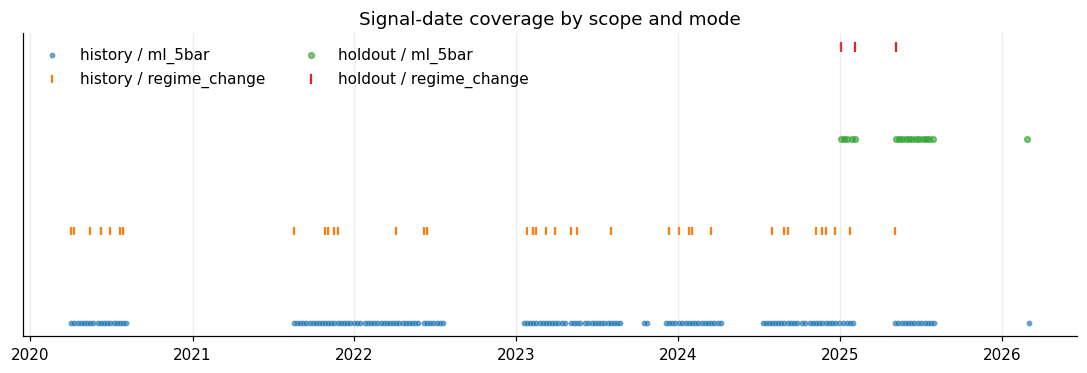

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ml_5bar = period_log.loc[(period_log['scope'] == 'history') & (period_log['mode'] == 'ml_5bar')]
ax.scatter(ml_5bar['signal_date'], np.ones(len(ml_5bar)), s=8, label='history / ml_5bar', alpha=0.6)
regime = period_log.loc[(period_log['scope'] == 'history') & (period_log['mode'] == 'regime_change')]
ax.scatter(regime['signal_date'], 1.05 + np.zeros(len(regime)), s=24, label='history / regime_change', marker='|')
h_ml = period_log.loc[(period_log['scope'] == 'holdout') & (period_log['mode'] == 'ml_5bar')]
ax.scatter(h_ml['signal_date'], 1.10 + np.zeros(len(h_ml)), s=14, label='holdout / ml_5bar', alpha=0.6)
h_reg = period_log.loc[(period_log['scope'] == 'holdout') & (period_log['mode'] == 'regime_change')]
ax.scatter(h_reg['signal_date'], 1.15 + np.zeros(len(h_reg)), s=36, marker='|', label='holdout / regime_change')
ax.set_yticks([])
ax.set_title('Signal-date coverage by scope and mode')
ax.legend(loc='upper left', ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## 4. Strategy summary table

In [7]:
metric_cols = [
    'total_return', 'cagr', 'sharpe', 'sortino', 'max_drawdown', 'calmar',
    'profit_factor', 'hit_rate', 'trade_count', 'period_count', 'turnover_per_year',
]
summary[['scope', 'mode', 'strategy_label', *metric_cols]].copy()

,scope,mode,strategy_label,total_return,cagr,sharpe,sortino,max_drawdown,calmar,profit_factor,hit_rate,trade_count,period_count,turnover_per_year
0,history,ml_5bar,Top 5 Holdings ML Rotation Stop 10%,0.734014,0.097217,0.795943,1.215939,-0.209693,0.463616,1.641075,0.375796,109,157,15.602026
1,history,ml_5bar,Sector ETF ML Quality Rotation,0.602366,0.082712,0.717606,1.054572,-0.205672,0.402154,1.601189,0.388535,104,157,15.205363
2,history,ml_5bar,SPY Buy And Hold,0.984901,0.122494,0.997731,1.419214,-0.224758,0.545004,1.677235,0.630573,1,157,0.000000
3,history,regime_change,Top 5 Holdings ML Rotation Stop 10%,1.822986,0.191153,0.919140,3.856783,-0.138466,1.380504,6.276817,0.405405,37,37,6.023442
4,history,regime_change,Sector ETF ML Quality Rotation,1.534369,0.169695,0.943253,2.802724,-0.167995,1.010120,5.467348,0.405405,37,37,6.453746
5,history,regime_change,SPY Buy And Hold,1.960096,0.200713,0.998902,2.681688,-0.198797,1.009635,3.790003,0.702703,1,37,0.000000
6,holdout,ml_5bar,Top 5 Holdings ML Rotation Stop 10%,0.194582,0.164674,1.657925,4.240822,-0.025750,6.395004,3.656101,0.611111,14,18,11.201434
7,holdout,ml_5bar,Sector ETF ML Quality Rotation,0.154816,0.131353,1.702642,8.506001,-0.013989,9.389700,3.999169,0.555556,11,18,10.334305
8,holdout,ml_5bar,SPY Buy And Hold,0.126564,0.107580,1.602882,5.451631,-0.022934,4.690837,2.984251,0.666667,1,18,0.000000
9,holdout,regime_change,Top 5 Holdings ML Rotation Stop 10%,0.418769,0.349734,1.398995,NaN,-0.001500,233.156228,267.978360,0.666667,3,3,2.572183


In [8]:
def _style_summary(frame: pd.DataFrame) -> pd.DataFrame:
    f = frame.copy()
    for col in ['total_return', 'cagr', 'max_drawdown', 'hit_rate', 'turnover_per_year']:
        if col in f.columns:
            f[col] = f[col].map(lambda v: f'{v*100:6.2f}%' if pd.notna(v) and col != 'turnover_per_year' else (f'{v:6.2f}' if pd.notna(v) else ''))
    for col in ['sharpe', 'sortino', 'calmar', 'profit_factor']:
        if col in f.columns:
            f[col] = f[col].map(lambda v: f'{v:6.2f}' if pd.notna(v) else '')
    return f

_style_summary(summary[['scope', 'mode', 'strategy_label', *metric_cols]])

,scope,mode,strategy_label,total_return,cagr,sharpe,sortino,max_drawdown,calmar,profit_factor,hit_rate,trade_count,period_count,turnover_per_year
0,history,ml_5bar,Top 5 Holdings ML Rotation Stop 10%,73.40%,9.72%,0.80,1.22,-20.97%,0.46,1.64,37.58%,109,157,15.60
1,history,ml_5bar,Sector ETF ML Quality Rotation,60.24%,8.27%,0.72,1.05,-20.57%,0.40,1.60,38.85%,104,157,15.21
2,history,ml_5bar,SPY Buy And Hold,98.49%,12.25%,1.00,1.42,-22.48%,0.55,1.68,63.06%,1,157,0.00
3,history,regime_change,Top 5 Holdings ML Rotation Stop 10%,182.30%,19.12%,0.92,3.86,-13.85%,1.38,6.28,40.54%,37,37,6.02
4,history,regime_change,Sector ETF ML Quality Rotation,153.44%,16.97%,0.94,2.80,-16.80%,1.01,5.47,40.54%,37,37,6.45
5,history,regime_change,SPY Buy And Hold,196.01%,20.07%,1.00,2.68,-19.88%,1.01,3.79,70.27%,1,37,0.00
6,holdout,ml_5bar,Top 5 Holdings ML Rotation Stop 10%,19.46%,16.47%,1.66,4.24,-2.58%,6.40,3.66,61.11%,14,18,11.20
7,holdout,ml_5bar,Sector ETF ML Quality Rotation,15.48%,13.14%,1.70,8.51,-1.40%,9.39,4.00,55.56%,11,18,10.33
8,holdout,ml_5bar,SPY Buy And Hold,12.66%,10.76%,1.60,5.45,-2.29%,4.69,2.98,66.67%,1,18,0.00
9,holdout,regime_change,Top 5 Holdings ML Rotation Stop 10%,41.88%,34.97%,1.40,,-0.15%,233.16,267.98,66.67%,3,3,2.57


## 5. Equity curves — history vs holdout

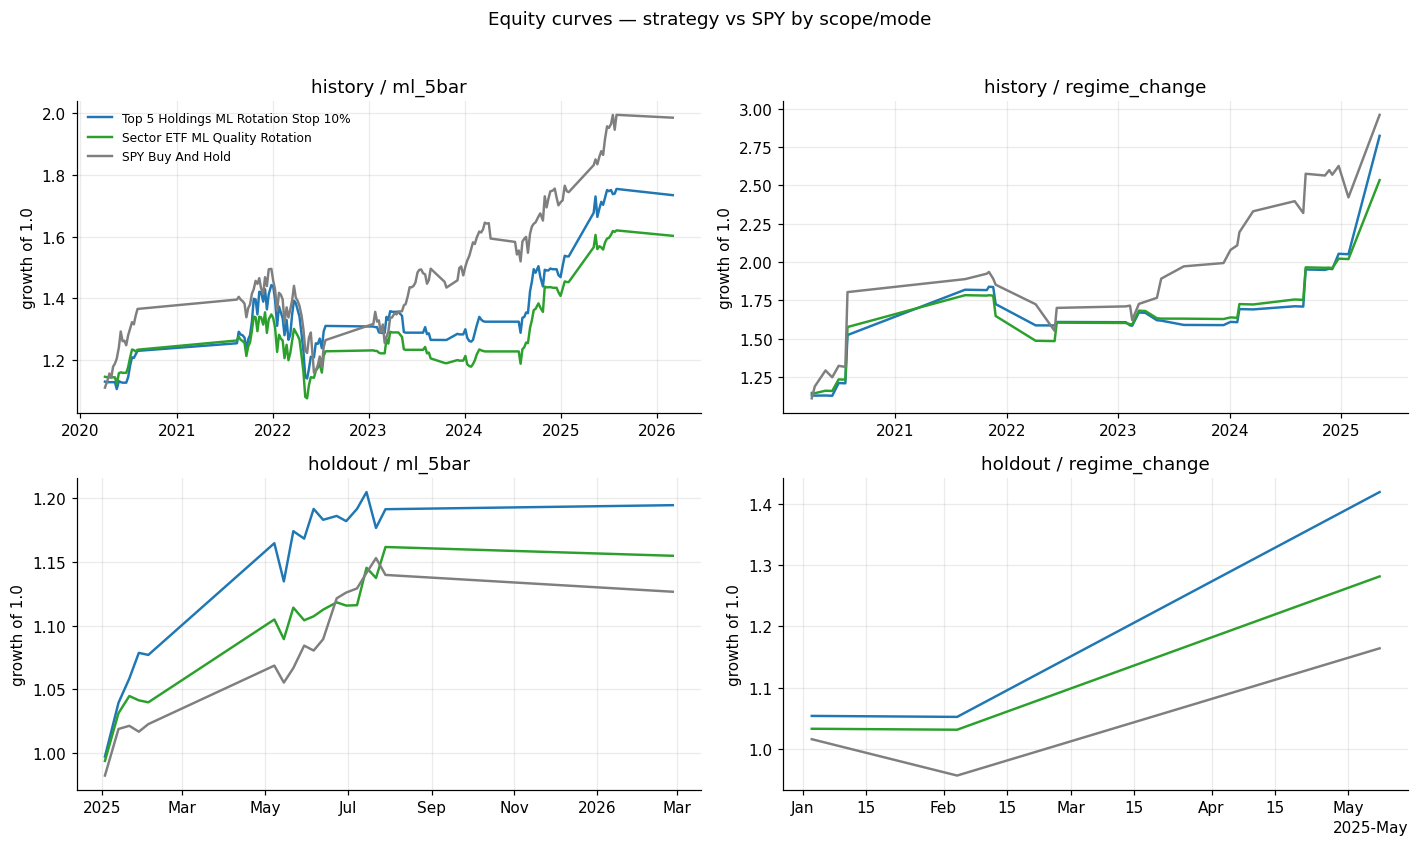

In [9]:
STRAT_COLS = {
    'Top 5 Holdings ML Rotation Stop 10%': ('equity_top5', 'stock_top5_return', '#1f77b4'),
    'Sector ETF ML Quality Rotation': ('equity_sector_quality', 'sector_quality_return', '#2ca02c'),
    'SPY Buy And Hold': ('equity_spy', 'spy_return', '#7f7f7f'),
}

def _plot_equity(ax, frame: pd.DataFrame, title: str) -> None:
    if frame.empty:
        ax.set_title(title + ' (no data)')
        return
    frame = frame.sort_values('entry_date').reset_index(drop=True)
    for label, (_, ret_col, color) in STRAT_COLS.items():
        equity = (1.0 + frame[ret_col].astype(float).fillna(0.0)).cumprod()
        ax.plot(frame['entry_date'], equity, label=label, color=color, linewidth=1.6)
    ax.set_title(title)
    ax.set_ylabel('growth of 1.0')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharey=False)
for ax, (scope, mode) in zip(
    axes.flatten(),
    [('history', 'ml_5bar'), ('history', 'regime_change'), ('holdout', 'ml_5bar'), ('holdout', 'regime_change')],
):
    frame = period_log[(period_log['scope'] == scope) & (period_log['mode'] == mode)]
    _plot_equity(ax, frame, f'{scope} / {mode}')
axes[0, 0].legend(loc='upper left', frameon=False, fontsize=8)
fig.suptitle('Equity curves — strategy vs SPY by scope/mode', y=1.02)
plt.tight_layout()
plt.show()

## 6. Drawdowns

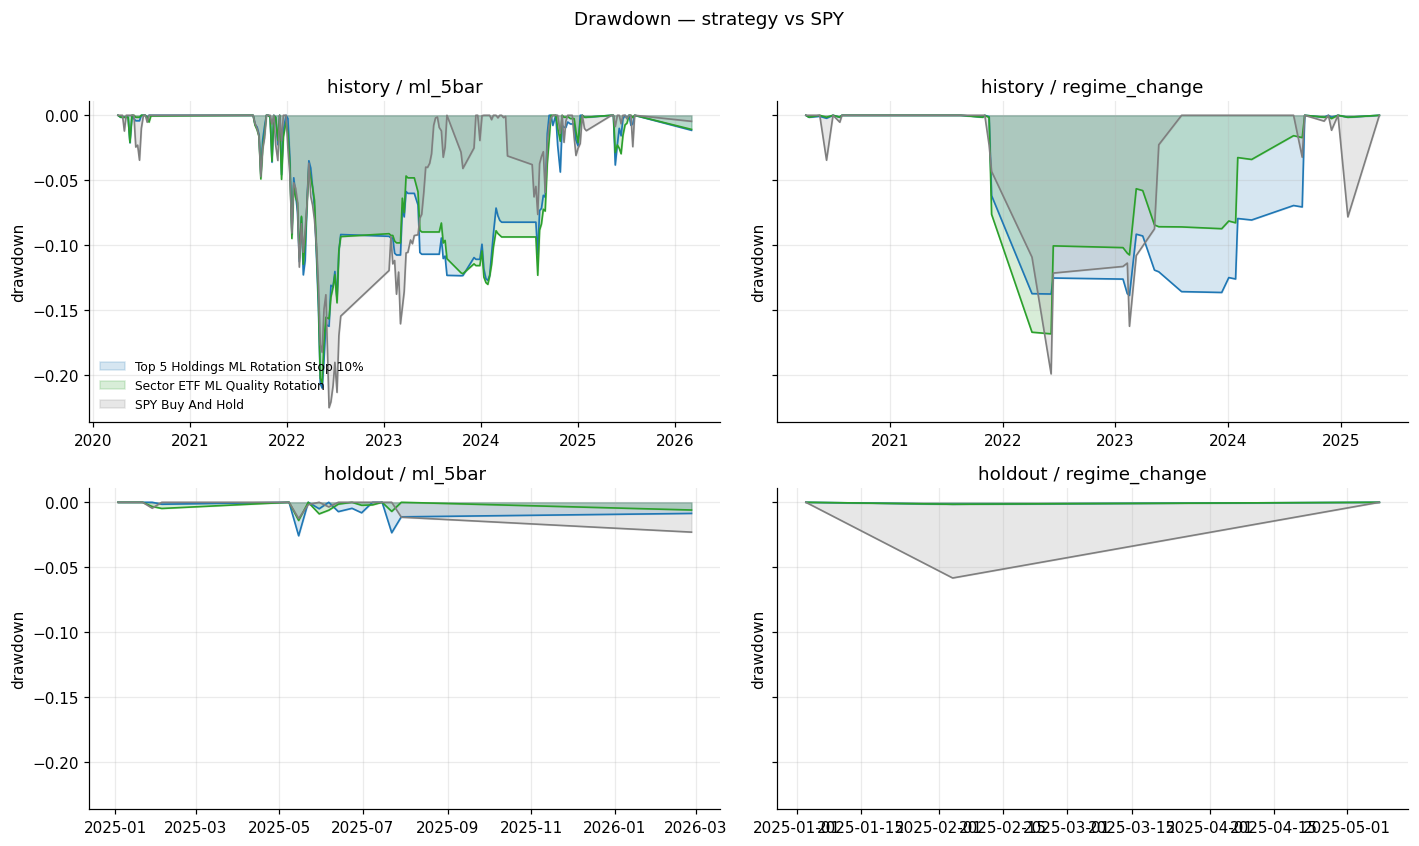

In [10]:
def _drawdown(returns: pd.Series) -> pd.Series:
    eq = (1.0 + returns.astype(float).fillna(0.0)).cumprod()
    return eq / eq.cummax() - 1.0

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharey=True)
for ax, (scope, mode) in zip(
    axes.flatten(),
    [('history', 'ml_5bar'), ('history', 'regime_change'), ('holdout', 'ml_5bar'), ('holdout', 'regime_change')],
):
    frame = period_log[(period_log['scope'] == scope) & (period_log['mode'] == mode)].sort_values('entry_date')
    if frame.empty:
        ax.set_title(f'{scope} / {mode} (no data)')
        continue
    for label, (_, ret_col, color) in STRAT_COLS.items():
        dd = _drawdown(frame[ret_col])
        ax.fill_between(frame['entry_date'], dd, color=color, alpha=0.18, label=label)
        ax.plot(frame['entry_date'], dd, color=color, linewidth=1.1)
    ax.set_title(f'{scope} / {mode}')
    ax.set_ylabel('drawdown')
axes[0, 0].legend(loc='lower left', frameon=False, fontsize=8)
fig.suptitle('Drawdown — strategy vs SPY', y=1.02)
plt.tight_layout()
plt.show()

## 7. Per-period return distribution

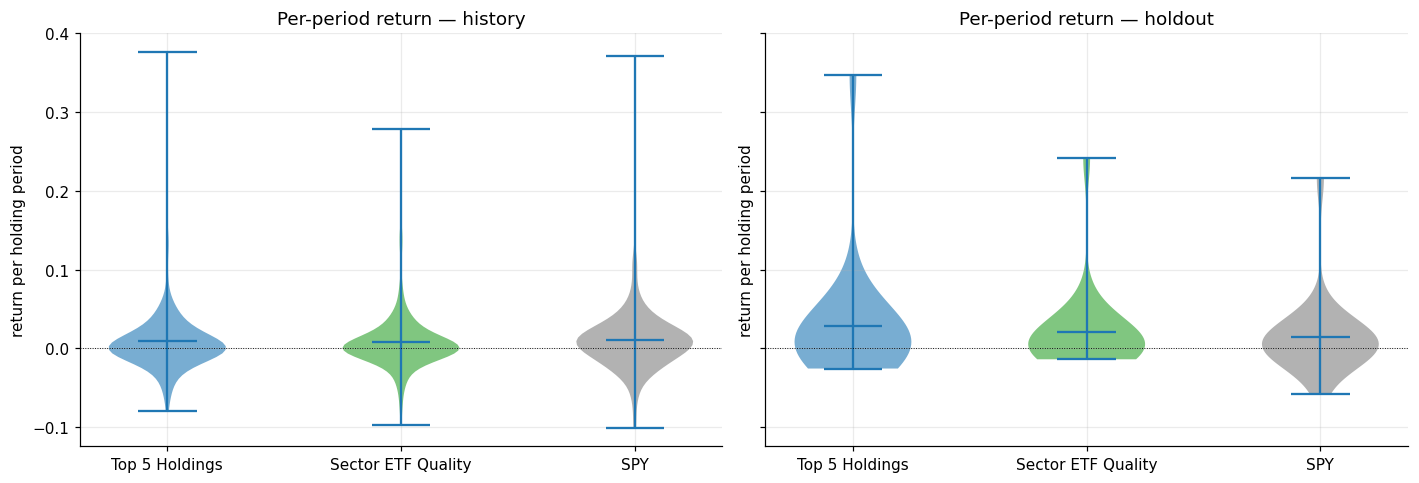

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, scope in zip(axes, ['history', 'holdout']):
    frame = period_log[period_log['scope'] == scope]
    if frame.empty:
        ax.set_title(f'{scope} (no data)')
        continue
    data = [frame['stock_top5_return'].dropna(), frame['sector_quality_return'].dropna(), frame['spy_return'].dropna()]
    labels = ['Top 5 Holdings', 'Sector ETF Quality', 'SPY']
    parts = ax.violinplot(data, showmeans=True, showmedians=False)
    for body, color in zip(parts['bodies'], ['#1f77b4', '#2ca02c', '#7f7f7f']):
        body.set_facecolor(color); body.set_alpha(0.6)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(labels)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_title(f'Per-period return — {scope}')
    ax.set_ylabel('return per holding period')
plt.tight_layout()
plt.show()

## 8. Returns by regime

In [12]:
regime_summary = (
    period_log.groupby(['scope', 'mode', 'regime_label'])
    .agg(
        top5_total=('stock_top5_return', lambda s: float((1 + s.fillna(0)).prod() - 1)),
        sector_quality_total=('sector_quality_return', lambda s: float((1 + s.fillna(0)).prod() - 1)),
        spy_total=('spy_return', lambda s: float((1 + s.fillna(0)).prod() - 1)),
        periods=('signal_date', 'count'),
    )
    .reset_index()
)
regime_summary

,scope,mode,regime_label,top5_total,sector_quality_total,spy_total,periods
0,history,ml_5bar,Cash,-0.024996,-0.025196,-0.117257,50
1,history,ml_5bar,Fragile Late-Cycle Watch,0.235306,0.239088,0.328755,9
2,history,ml_5bar,Inflationary Boom,0.169348,0.062293,0.190971,51
3,history,ml_5bar,Liquidity Bubble Or Valuation Stretch,0.317318,0.312778,0.356389,31
4,history,ml_5bar,Rate-Shock Regime,-0.065375,-0.048722,0.047548,16
5,history,regime_change,Cash,-0.021467,-0.025196,-0.097107,17
6,history,regime_change,Fragile Late-Cycle Watch,0.530389,0.582986,0.755141,4
7,history,regime_change,Inflationary Boom,0.219293,0.143617,0.261041,8
8,history,regime_change,Liquidity Bubble Or Valuation Stretch,0.679119,0.479733,0.446343,5
9,history,regime_change,Rate-Shock Regime,-0.079250,-0.029463,0.024134,3


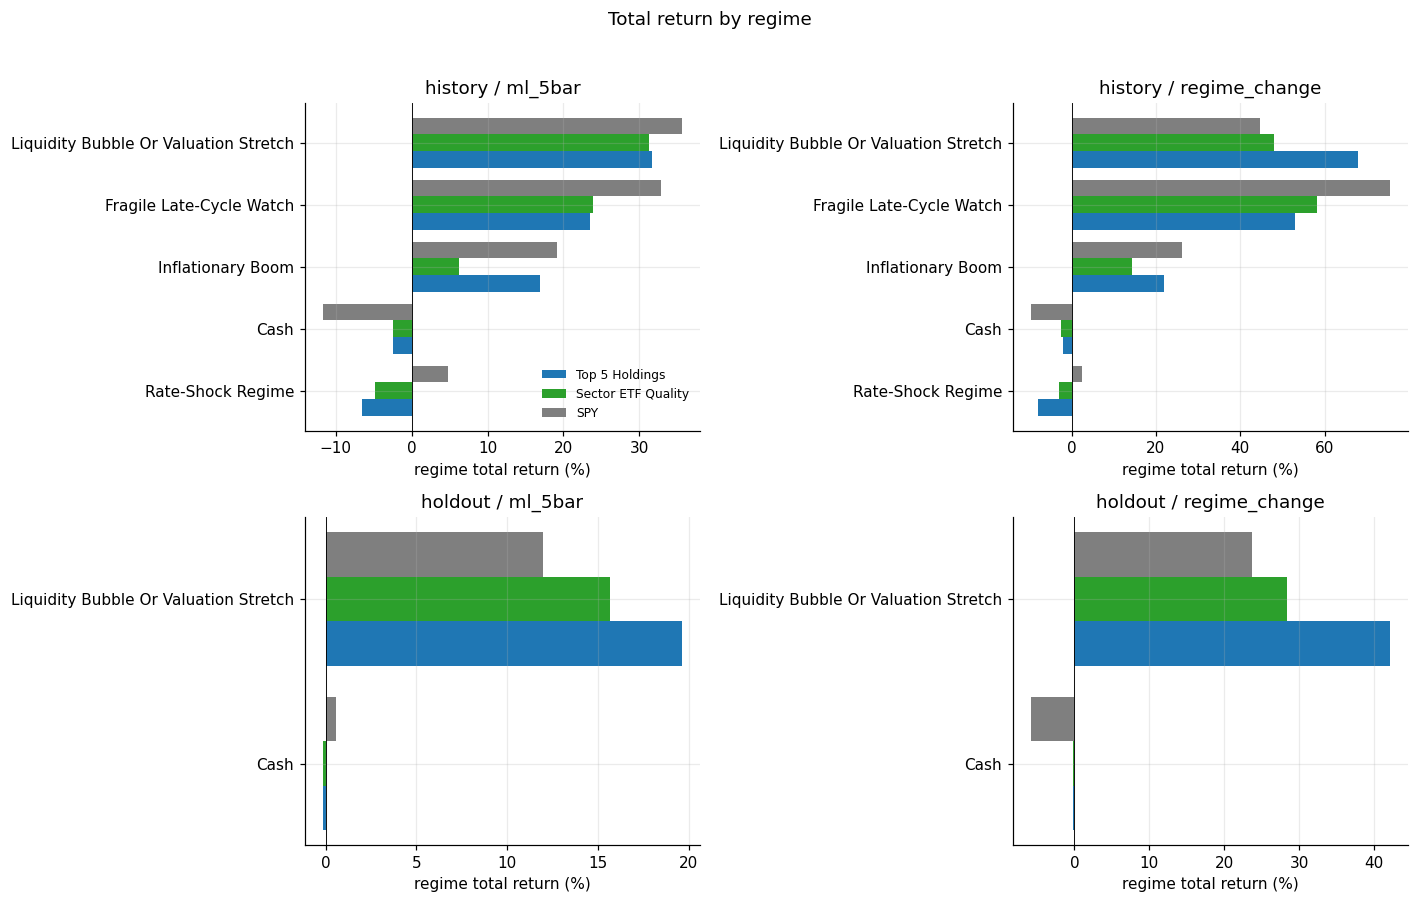

In [13]:
def _plot_regime_bar(ax, scope: str, mode: str) -> None:
    frame = regime_summary[(regime_summary['scope'] == scope) & (regime_summary['mode'] == mode)].copy()
    if frame.empty:
        ax.set_title(f'{scope} / {mode} (no data)')
        return
    frame = frame.sort_values('top5_total', ascending=True)
    y = np.arange(len(frame))
    width = 0.27
    ax.barh(y - width, frame['top5_total'] * 100, width, label='Top 5 Holdings', color='#1f77b4')
    ax.barh(y, frame['sector_quality_total'] * 100, width, label='Sector ETF Quality', color='#2ca02c')
    ax.barh(y + width, frame['spy_total'] * 100, width, label='SPY', color='#7f7f7f')
    ax.set_yticks(y); ax.set_yticklabels(frame['regime_label'])
    ax.set_xlabel('regime total return (%)')
    ax.set_title(f'{scope} / {mode}')
    ax.axvline(0, color='black', linewidth=0.6)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (scope, mode) in zip(
    axes.flatten(),
    [('history', 'ml_5bar'), ('history', 'regime_change'), ('holdout', 'ml_5bar'), ('holdout', 'regime_change')],
):
    _plot_regime_bar(ax, scope, mode)
axes[0, 0].legend(loc='lower right', frameon=False, fontsize=8)
fig.suptitle('Total return by regime', y=1.02)
plt.tight_layout()
plt.show()

## 9. Turnover and trading cost

In [14]:
turnover_summary = (
    period_log.groupby(['scope', 'mode'])
    .agg(
        avg_turnover=('turnover', 'mean'),
        total_turnover=('turnover', 'sum'),
        total_turnover_cost=('turnover_cost', 'sum'),
        avg_holdings=('selected_stock_count', 'mean'),
        avg_sectors=('selected_sector_count', 'mean'),
    )
    .reset_index()
)
turnover_summary

,scope,mode,avg_turnover,total_turnover,total_turnover_cost,avg_holdings,avg_sectors
0,history,ml_5bar,0.589590,92.565611,0.138848,7.197452,1.439490
1,history,regime_change,0.965854,35.736615,0.053605,5.270270,1.054054
2,holdout,ml_5bar,0.725806,13.064506,0.019597,7.777778,1.555556
3,holdout,regime_change,1.000000,3.000000,0.004500,10.000000,2.000000


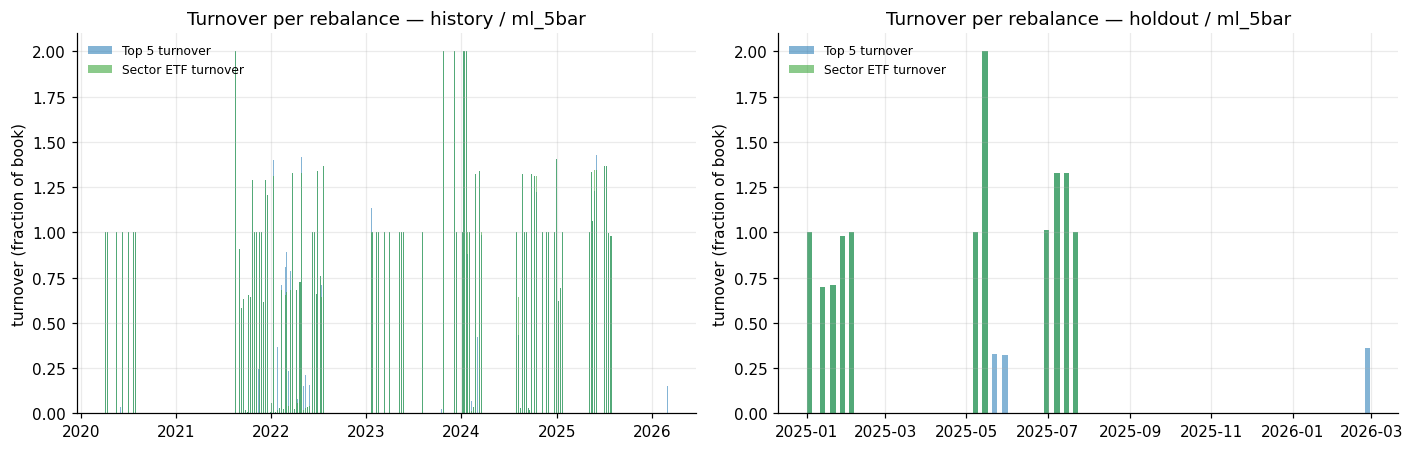

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, scope in zip(axes, ['history', 'holdout']):
    frame = period_log[(period_log['scope'] == scope) & (period_log['mode'] == 'ml_5bar')].sort_values('entry_date')
    if frame.empty:
        ax.set_title(f'{scope} / ml_5bar (no data)')
        continue
    ax.bar(frame['entry_date'], frame['turnover'], width=4.0, color='#1f77b4', alpha=0.55, label='Top 5 turnover')
    ax.bar(frame['entry_date'], frame['sector_turnover'], width=4.0, color='#2ca02c', alpha=0.55, label='Sector ETF turnover')
    ax.set_title(f'Turnover per rebalance — {scope} / ml_5bar')
    ax.set_ylabel('turnover (fraction of book)')
    ax.legend(loc='upper left', frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 10. Stop-loss activity

In [16]:
stop_summary = (
    period_log.groupby(['scope', 'mode'])
    .agg(
        periods=('signal_date', 'count'),
        total_stop_count=('stop_count', 'sum'),
        periods_with_stop=('stop_count', lambda s: int((s > 0).sum())),
    )
    .reset_index()
)
stop_summary['stop_rate'] = stop_summary['periods_with_stop'] / stop_summary['periods']
stop_summary

,scope,mode,periods,total_stop_count,periods_with_stop,stop_rate
0,history,ml_5bar,157,32,19,0.121019
1,history,regime_change,37,34,10,0.270270
2,holdout,ml_5bar,18,1,1,0.055556
3,holdout,regime_change,3,3,1,0.333333


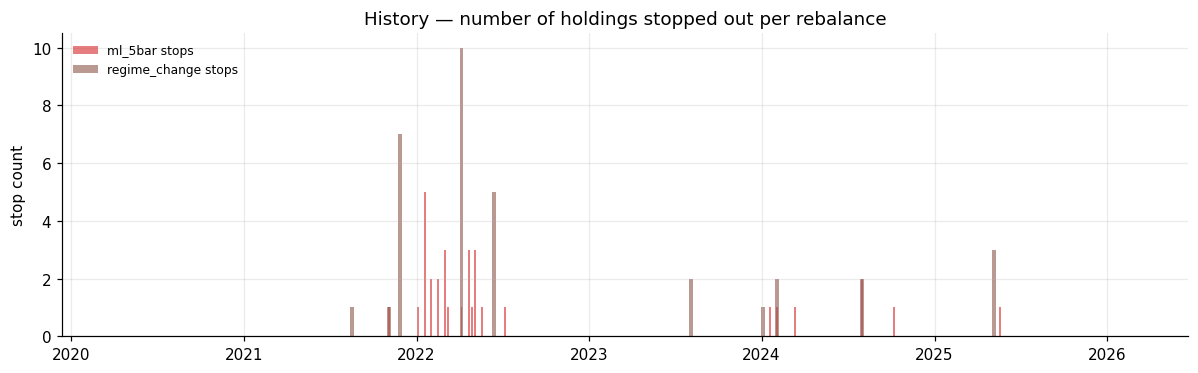

In [17]:
frame = period_log[period_log['scope'] == 'history'].sort_values('entry_date')
fig, ax = plt.subplots(figsize=(11, 3.5))
ml = frame[frame['mode'] == 'ml_5bar']
regime = frame[frame['mode'] == 'regime_change']
ax.bar(ml['entry_date'], ml['stop_count'], width=4.0, color='#d62728', alpha=0.6, label='ml_5bar stops')
ax.bar(regime['entry_date'], regime['stop_count'], width=8.0, color='#8c564b', alpha=0.6, label='regime_change stops')
ax.set_title('History — number of holdings stopped out per rebalance')
ax.set_ylabel('stop count')
ax.legend(loc='upper left', frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 11. Leaderboard and best-strategy assessment

The leaderboard ranks each (mode, strategy) candidate on the **history** slice using (Sharpe → CAGR → max drawdown), then carries the unchanged winner into the **holdout** scope. `selected_on_history == True` identifies the candidate that the rule actually deploys; the `holdout_oracle_*` fields in the assessment JSON give the ex-post best to make the selection-vs-holdout gap explicit.

In [18]:
lb = leaderboard.copy()
ordered = lb.sort_values('history_rank')
ordered[[
    'mode', 'strategy_label',
    'history_rank', 'history_sharpe', 'history_cagr', 'history_max_drawdown',
    'holdout_rank', 'holdout_sharpe', 'holdout_cagr', 'holdout_max_drawdown',
    'holdout_total_return', 'benchmark_holdout_total_return', 'holdout_total_return_vs_spy',
    'selected_on_history',
]]

,mode,strategy_label,history_rank,history_sharpe,history_cagr,history_max_drawdown,holdout_rank,holdout_sharpe,holdout_cagr,holdout_max_drawdown,holdout_total_return,benchmark_holdout_total_return,holdout_total_return_vs_spy,selected_on_history
0,regime_change,Sector ETF ML Quality Rotation,1,0.943253,0.169695,-0.167995,4,1.363479,0.236952,-0.001500,0.281485,0.164475,0.117010,True
1,regime_change,Top 5 Holdings ML Rotation Stop 10%,2,0.919140,0.191153,-0.138466,3,1.398995,0.349734,-0.001500,0.418769,0.164475,0.254295,False
2,ml_5bar,Top 5 Holdings ML Rotation Stop 10%,3,0.795943,0.097217,-0.209693,2,1.657925,0.164674,-0.025750,0.194582,0.126564,0.068018,False
3,ml_5bar,Sector ETF ML Quality Rotation,4,0.717606,0.082712,-0.205672,1,1.702642,0.131353,-0.013989,0.154816,0.126564,0.028253,False


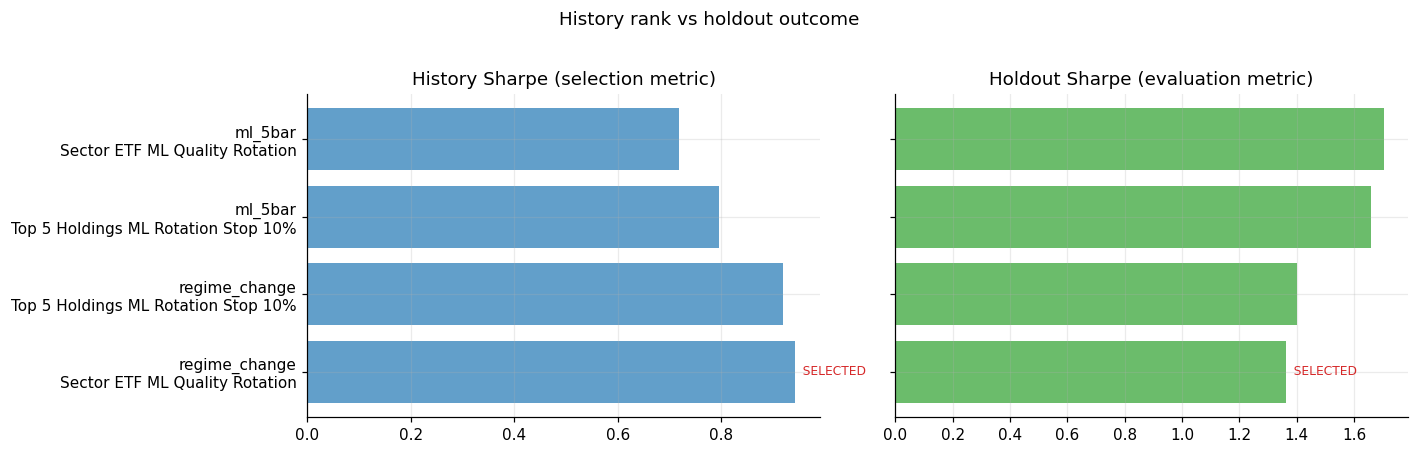

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
ord_lb = leaderboard.sort_values('history_rank').reset_index(drop=True)
labels = [f"{m}\n{s}" for m, s in zip(ord_lb['mode'], ord_lb['strategy_label'])]
y = np.arange(len(ord_lb))
axes[0].barh(y, ord_lb['history_sharpe'], color='#1f77b4', alpha=0.7)
axes[0].set_yticks(y); axes[0].set_yticklabels(labels)
axes[0].set_title('History Sharpe (selection metric)')
axes[0].axvline(0, color='black', linewidth=0.6)
axes[1].barh(y, ord_lb['holdout_sharpe'], color='#2ca02c', alpha=0.7)
axes[1].set_yticks(y); axes[1].set_yticklabels([])
axes[1].set_title('Holdout Sharpe (evaluation metric)')
axes[1].axvline(0, color='black', linewidth=0.6)
selected_idx = ord_lb.index[ord_lb['selected_on_history']].tolist()
for idx in selected_idx:
    axes[0].text(ord_lb.loc[idx, 'history_sharpe'], idx, '  SELECTED', va='center', fontsize=8, color='#d62728')
    axes[1].text(ord_lb.loc[idx, 'holdout_sharpe'], idx, '  SELECTED', va='center', fontsize=8, color='#d62728')
fig.suptitle('History rank vs holdout outcome', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
fields = [
    'selection_rule', 'candidate_count',
    'selected_mode', 'selected_strategy_label',
    'selected_history_rank', 'selected_holdout_rank',
    'history_total_return', 'history_cagr', 'history_sharpe', 'history_max_drawdown',
    'holdout_total_return', 'holdout_cagr', 'holdout_sharpe', 'holdout_max_drawdown',
    'holdout_total_return_vs_spy', 'holdout_cagr_vs_spy', 'holdout_sharpe_vs_spy',
    'benchmark_holdout_total_return', 'benchmark_holdout_cagr', 'benchmark_holdout_sharpe', 'benchmark_holdout_max_drawdown',
    'holdout_oracle_mode', 'holdout_oracle_strategy_label', 'holdout_oracle_rank',
    'holdout_oracle_total_return', 'holdout_oracle_cagr', 'holdout_oracle_sharpe',
]
assessment_view = pd.DataFrame({'field': fields, 'value': [assessment.get(k) for k in fields]})
assessment_view

,field,value
0,selection_rule,Rank candidate PIT strategies by history Sharp...
1,candidate_count,4
2,selected_mode,regime_change
3,selected_strategy_label,Sector ETF ML Quality Rotation
4,selected_history_rank,1
5,selected_holdout_rank,4
6,history_total_return,1.534369
7,history_cagr,0.169695
8,history_sharpe,0.943253
9,history_max_drawdown,-0.167995


## 12. Sector exposure heatmap

Per-period sector weight in the Top-5-holdings rotation. Helps spot regime-conditional concentration (e.g. defensive bias under fragile late-cycle, cyclical tilt under inflationary boom).

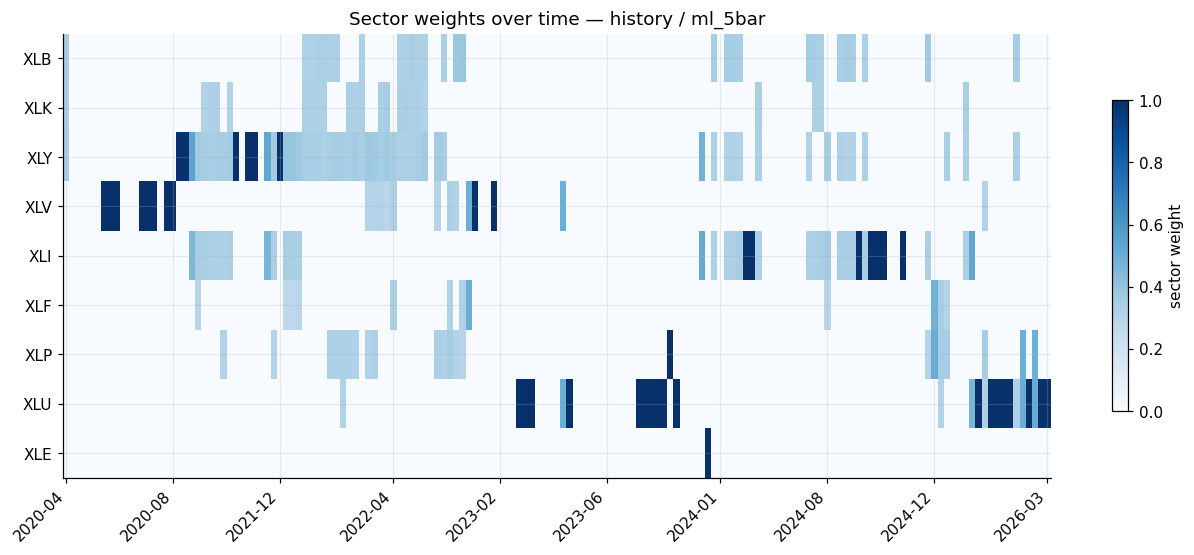

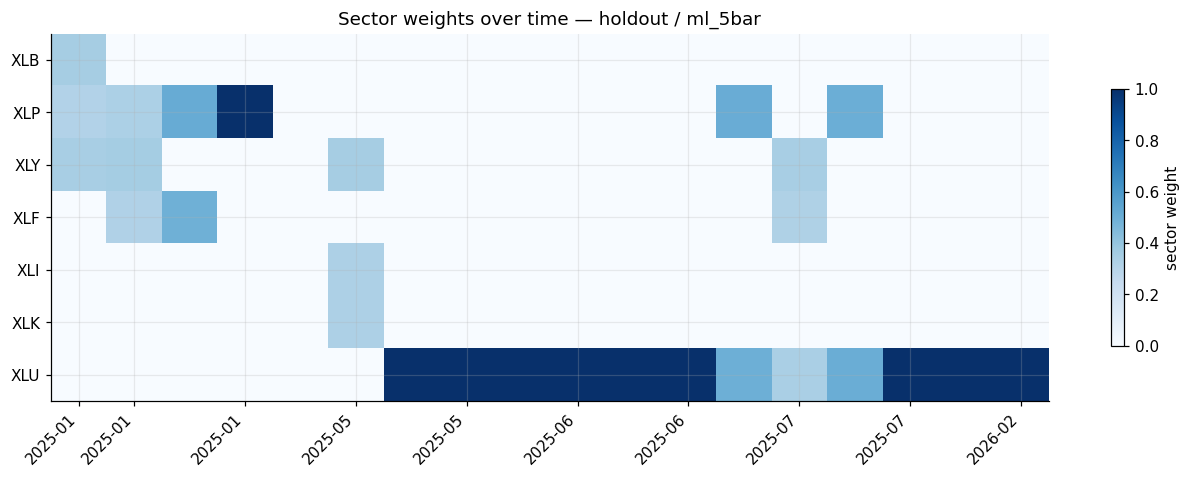

In [21]:
def _weight_matrix(scope: str, mode: str) -> pd.DataFrame:
    frame = period_log[(period_log['scope'] == scope) & (period_log['mode'] == mode)].copy()
    if frame.empty:
        return pd.DataFrame()
    rows = []
    for _, row in frame.iterrows():
        try:
            weights = json.loads(row['sector_weights'])
        except Exception:
            weights = {}
        rows.append({'entry_date': row['entry_date'], **weights})
    matrix = pd.DataFrame(rows).set_index('entry_date').sort_index()
    matrix = matrix.fillna(0.0)
    return matrix

for scope, mode in [('history', 'ml_5bar'), ('holdout', 'ml_5bar')]:
    matrix = _weight_matrix(scope, mode)
    if matrix.empty:
        print(f'{scope} / {mode}: empty')
        continue
    fig, ax = plt.subplots(figsize=(12, 0.35 * max(matrix.shape[1], 3) + 2.0))
    im = ax.imshow(matrix.T.values, aspect='auto', cmap='Blues', vmin=0.0, vmax=matrix.values.max())
    ax.set_yticks(np.arange(len(matrix.columns)))
    ax.set_yticklabels(matrix.columns)
    sample_idx = np.linspace(0, len(matrix.index) - 1, num=min(10, len(matrix.index))).astype(int)
    ax.set_xticks(sample_idx)
    ax.set_xticklabels([matrix.index[i].strftime('%Y-%m') for i in sample_idx], rotation=45, ha='right')
    ax.set_title(f'Sector weights over time — {scope} / {mode}')
    fig.colorbar(im, ax=ax, shrink=0.7, label='sector weight')
    plt.tight_layout()
    plt.show()

## 13. Conclusions and known caveats

**What we found.**

- The PIT runner now reads the split OOS signal exports and produces a real train-to-holdout assessment (`sector_ml_pit_top5_holdings_leaderboard.csv`, `sector_ml_pit_top5_holdings_best_strategy_assessment.json`).
- The history-selected winner (`regime_change / Sector ETF ML Quality Rotation`) generalized to the holdout with **+28.1% total return** (Sharpe 1.36) and **+11.7 pts vs SPY**, but ranked 4 of 4 vs the ex-post oracle. Selection-vs-oracle gap is the right thing to surface — the strategy did beat SPY, but the rule did not pick the best of the four candidates with hindsight.
- The `ml_5bar / Sector ETF ML Quality Rotation` candidate was the ex-post oracle on holdout (Sharpe 1.70, +2.8 pts vs SPY) but only ranked 4 of 4 on history. If you want the deployable 5-bar lane to drive selection, you can restrict the candidate set to `ml_5bar` and leave `regime_change` as a diagnostic.

**Forward-bias status.**

- PIT holdings filter: clean (`known_from_date <= signal_date` enforced at load and at consumption).
- Validation-quality prior: clean (year-strict pre-signal folds only).
- Holdout isolation: clean (train_end < holdout_start - embargo - purge).
- Macro pipeline: previously had a full-sample VIX3M backfill and a `bfill()` on spot VIX; both replaced with causal equivalents. To pick up the fix, regenerate the macro store (`./.venv/bin/python build_macro_store.py`) and re-run `build_sector_rotation_report.py` and `backtest_top_holdings_rotation.py`.

**Known caveats.**

- `ATVI`, `PXD`, `RTN`, `UTX` are skipped — no local price history (delisted/renamed). The runner reports them in the missing-symbols log but does not crash.
- The holdout window is short (~18 ml_5bar periods, 3 regime_change periods) — point estimates of Sharpe on the holdout are noisy. Treat the holdout as a falsification check, not a precision estimate.
- 10% stop is end-of-day; intraday breaches that recover by close are not modeled.
